## Annotation Visualization Tool

The following tool helps visualize annotations generated from the pipeline by overlaying them onto images.

Import data under the `annots` parameter. This should be a path to the post CA classifier annotation file. Save data via the `out_dir` param.

Please specify whether the data is in video or image mode through the parameter `--video_mode`, which is boolean.

There are FOUR ways to generate annotations:
1. Use `--num_images n` to generate the annotations for n images
2. Use `--all` to generate the annotations for all images
3. Use `--image_paths {p1} {p2} ...` to generate the annotations for specific images
4. Use `--annot-uuids {uuid1} {uuid2} ...` to generate for specific annotations

To specify which fields to include on each annotation, see the following list of optional parameters:

- `--detection_class` -- The class returned by the detector
- `--species` -- The species returned by the species identifier
- `--tracking_id` -- The tracking id assigned by the detector
- `--confidence` -- The strength of the bounding box detection from the detector
- `--viewpoint` -- The viewpoint
- `--CA_score` -- The CA annotation score
- `--annotations_census` -- The boolean signifying whether the annotation was kept or rejected

As of now, this step will read in the CSV format outputted by CA Classifier, before the preceeding preprocessing step which converts it to JSON and reformats data. **This will be refactored once formatting for each stage is standardized and file path is stored in annotations!**

TODO RAFACTORS:
- Revise flag inputs to match a standardized JSON output
- Allow absolute paths in --image_paths
- Add more flags
- Improve output coloring & formatting

Example Executions:
python3 visualize.py {video/image data json} {CA Output CSV} {Output Directory} --num_images 100 --CA_score --species --confidence --viewpoint
python3 visualize.py {video/image data json} {CA Output CSV} {Output Directory} --video_mode --image_paths {p1} {p2} {p3} ... --CA_score --species --confidence --viewpoint

python3 visualize.py /fs/ess/PAS2136/ggr_data/results/GGR2020_subset/image_data.json /fs/ess/PAS2136/ggr_data/results/GGR2020_subset/ca_classifier/final_output_with_softmax_and_census.csv annot_dir --all --species --viewpoint --CA_score

In [2]:
# Arguments -- fill this in based on desired requests
FIELDS = 'detection_class'
VIDEO_MODE = False
ANNOT_METHOD = 'all'

IMG_DIR = '/fs/ess/PAS2136/ggr_data/results/izzy_test/image_data.json'
ANNOTS_DIR = '/fs/ess/PAS2136/ggr_data/results/izzy_test/lca/lca_left_annots.json'

In [3]:
import numpy as np
import pandas as pd
import json
import cv2
import matplotlib.pyplot as plt
import os

In [4]:
with open(ANNOTS_DIR, 'r') as file:
    annots = json.load(file)

with open(IMG_DIR, 'r') as file:
    metadata = json.load(file)

# Step 1: Get the list of all valid image uris from metadata file
if VIDEO_MODE:
    image_metadata = []
    [image_metadata.extend(video["frame data"]) for video in metadata["videos"]]
else:
    image_metadata = metadata["images"]

uri_list = []
uri_uuid_mapping = {}
for image in image_metadata:
    uri_list.append(image["uri_original"])
    uri_uuid_mapping[image["uri_original"]] = image["uuid"]

# Step 2: Get the list of appropriate URIs to display

# Case 1: Use all images
if ANNOT_METHOD:
    images = uri_list

# Case 2: A list was provided. Only take in valid strs (we will cross check later if they exist in annots)
elif args.image_paths is not None:
    images_input = [path for path in args.image_paths if isinstance(path,str)]
    images = list(set(images_input) & set(uri_list))

# Case 3: No list was provided. Take in at most num_images random images
elif args.num_images is not None:
    rands = np.random.choice(len(uri_list), args.num_images, replace=False)
    images = list(np.array(uri_list)[rands])

# Case 4: Invalid input
else:
    raise Exception("Invalid inputs. Must specify either num_images, image_paths, or all.")

# GET THE ANNOTATIONS CORRESPONDING TO EACH URI

images_df = pd.DataFrame(images, columns=["uri"])
images_df["image_uuid"] = images_df["uri"].map(uri_uuid_mapping)

with open(ANNOTS_DIR, "r") as f:
    data = json.load(f)
    annot_df = pd.DataFrame(data["annotations"])

# Inner join because we can process this via a select w/ no returns
df = pd.merge(images_df, annot_df, on="image_uuid", how="inner")

24
0    3f7a129f-ccba-5ffa-f08b-3f6d7926a624
1    3f7a129f-ccba-5ffa-f08b-3f6d7926a624
Name: image_uuid, dtype: object


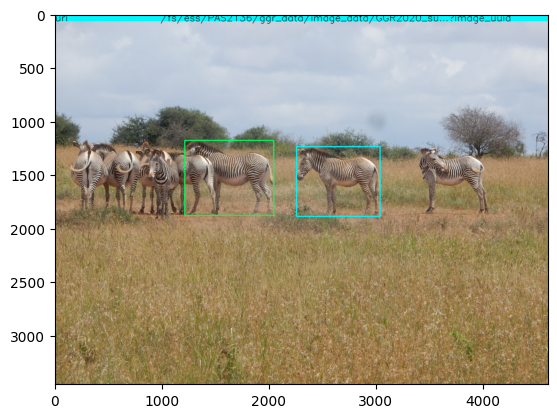

12
2    edaa0b74-c129-0039-c414-612c56939ced
Name: image_uuid, dtype: object


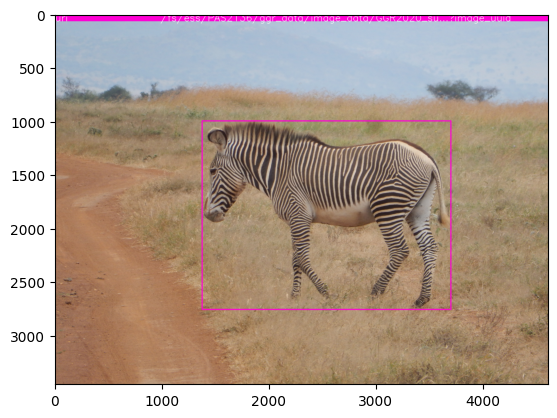

12
3    6c47a140-33c8-78dd-b50d-fd5c1e0fe6fa
Name: image_uuid, dtype: object


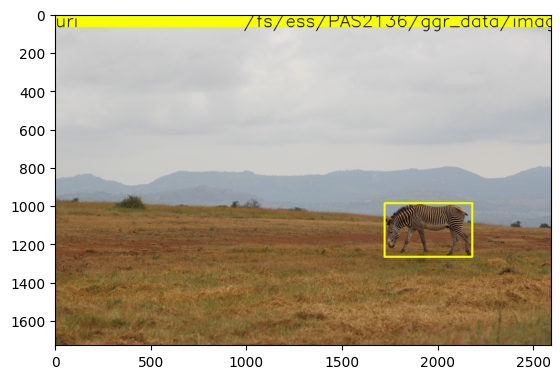

12
4    dc804433-cc2c-d778-0a53-27eb18a24d1a
Name: image_uuid, dtype: object


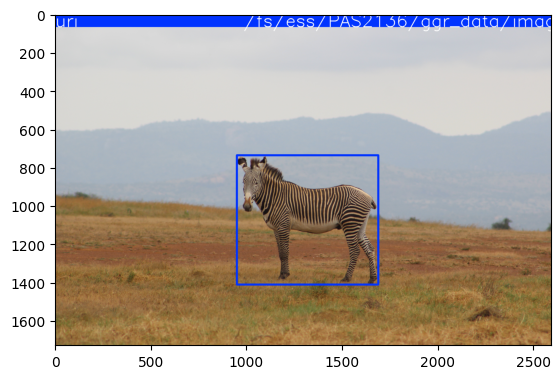

12
5    2fd8fe38-3719-f8ca-135d-70c936f84c00
Name: image_uuid, dtype: object


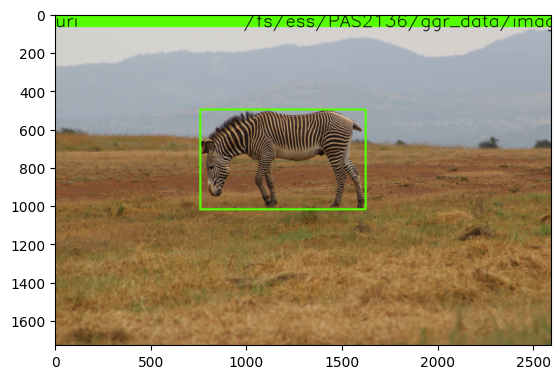

12
6    6197cfbc-f54c-36d2-c8ea-e9ecbd4d46b5
Name: image_uuid, dtype: object


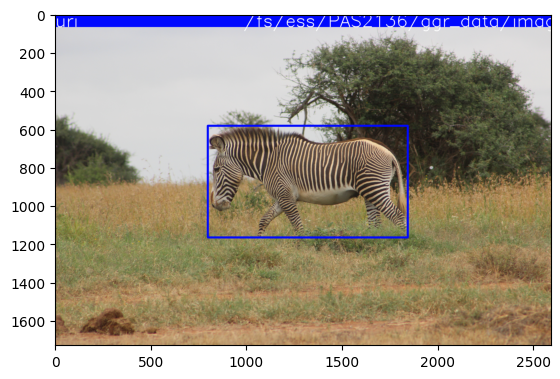

12
7    5d9758bd-6205-0bd8-f6c9-5ff02b2110e4
Name: image_uuid, dtype: object


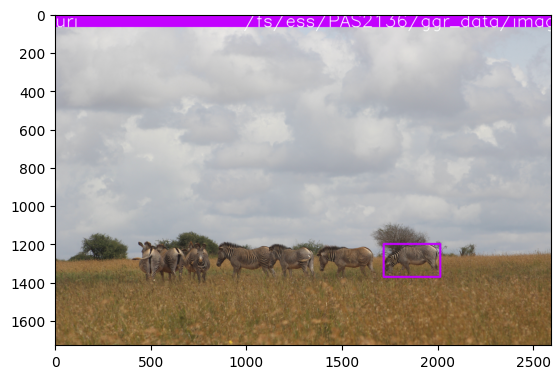

12
8    30f8c2e2-f364-519b-9e32-bd1aad3f84be
Name: image_uuid, dtype: object


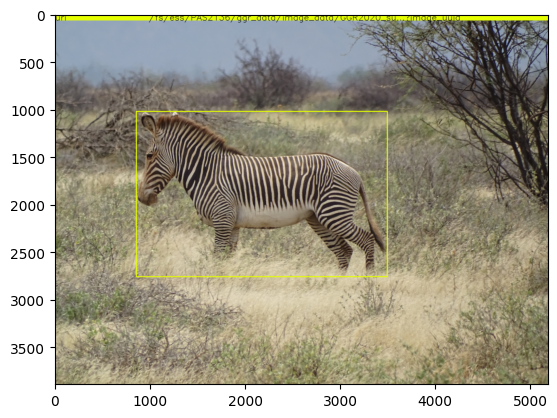

12
9    29affa51-6c79-23d7-b760-957de4a2b506
Name: image_uuid, dtype: object


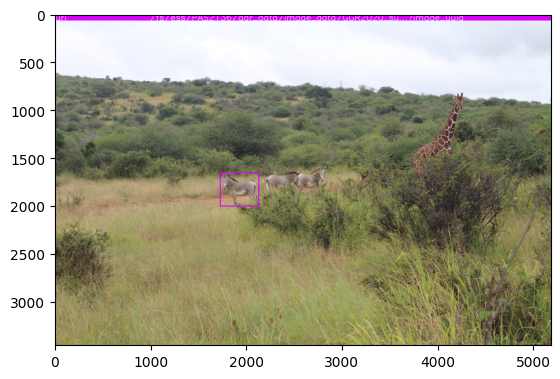

12
10    f79fb40d-6e22-9d21-6ff6-5a2ac92eff93
Name: image_uuid, dtype: object


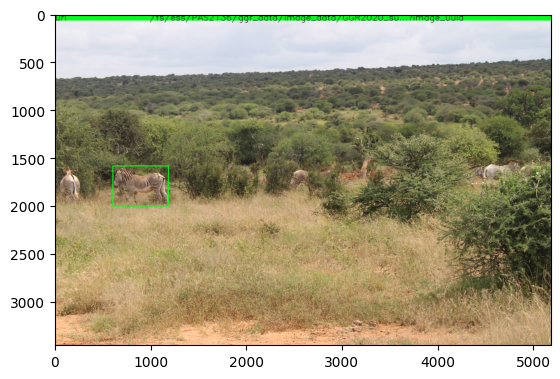

12
11    535175db-a97f-900e-a8b3-356e3788f4a9
Name: image_uuid, dtype: object


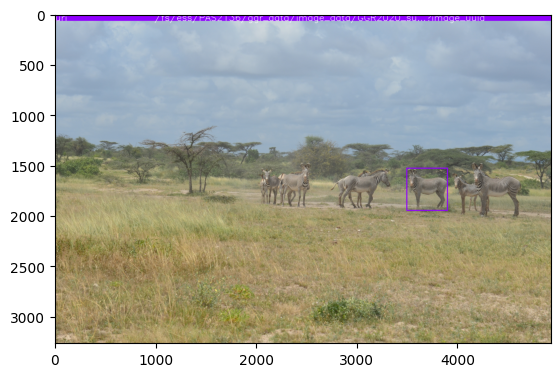

12
12    2b532efb-5db4-77bd-1e62-3b3a2b839eb9
Name: image_uuid, dtype: object


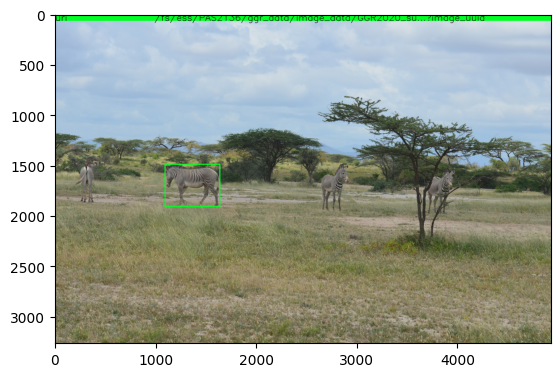

12
13    58401ad3-2d13-9885-cdfd-0b1b28e2bc1b
Name: image_uuid, dtype: object


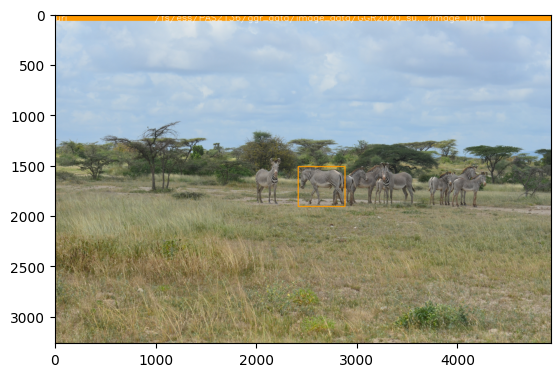

12
14    06bd7691-a76e-b1a0-00bb-f149f0ab941d
Name: image_uuid, dtype: object


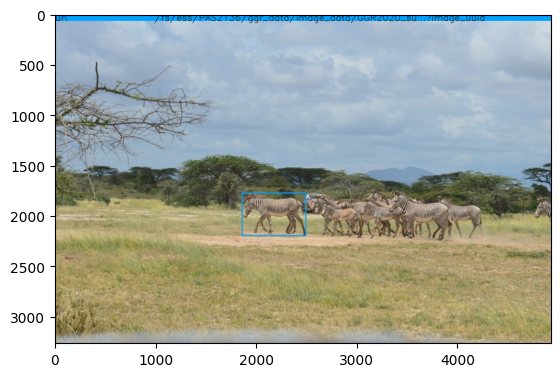

12
15    53ad8b17-be81-b77d-a525-d77f69e0bea9
Name: image_uuid, dtype: object


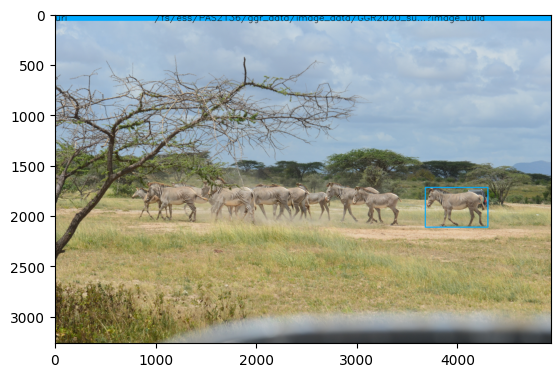

12
16    17b6eed5-1024-7130-2051-7880833cbb3d
Name: image_uuid, dtype: object


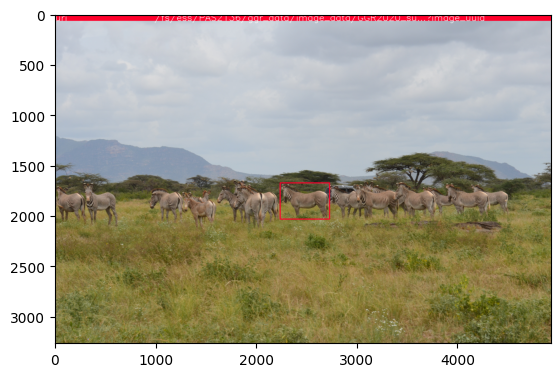

12
17    35a29a34-c927-2d1f-deb4-05f22095a2a0
Name: image_uuid, dtype: object


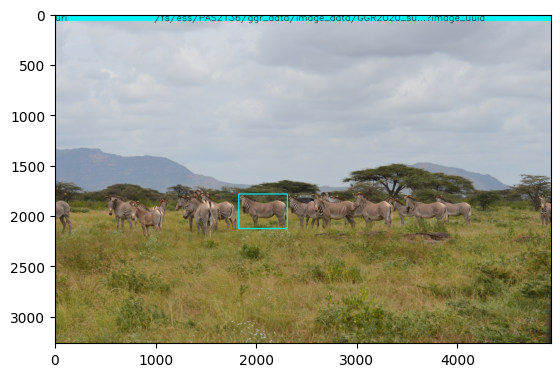

12
18    f1f79cd0-f9da-f744-4d40-39d9400e1f6c
Name: image_uuid, dtype: object


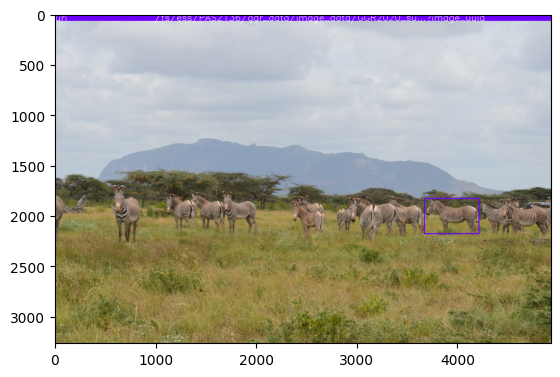

24
19    18c7b491-a576-6b00-3131-5ad784524195
20    18c7b491-a576-6b00-3131-5ad784524195
Name: image_uuid, dtype: object


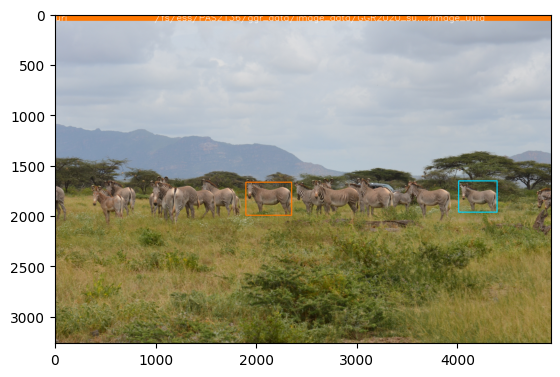

12
21    dae53b0a-b0d5-6014-bbe0-9aa2ed660519
Name: image_uuid, dtype: object


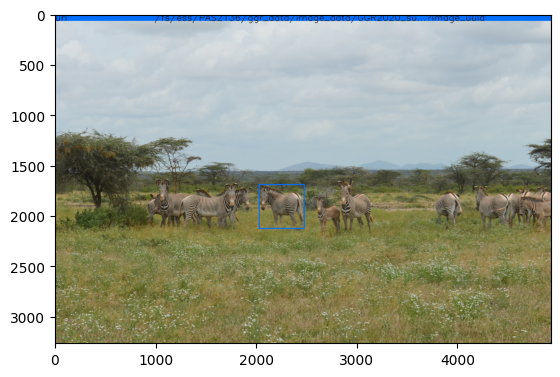

12
22    6b6d2709-560b-fb55-f80d-236d7a8a0eeb
Name: image_uuid, dtype: object


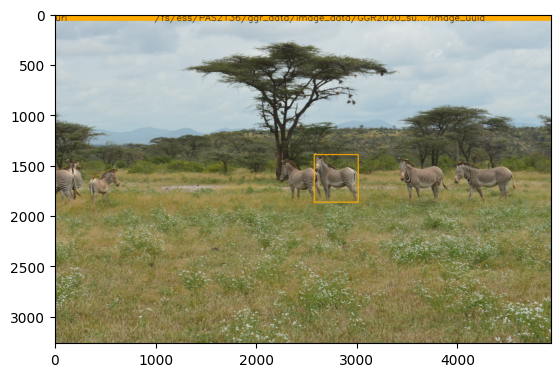

12
23    20a3a85d-9406-53b4-e4ad-84dbae5010aa
Name: image_uuid, dtype: object


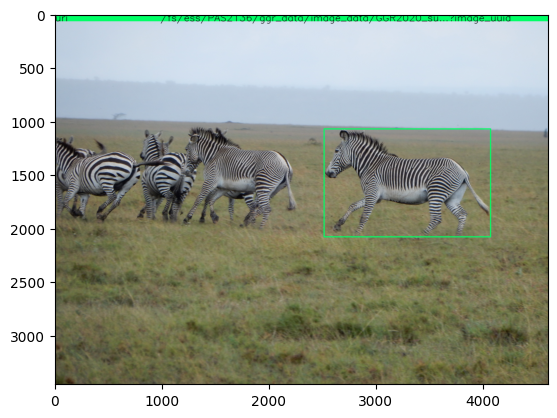

24
24    8bdd9571-1243-e4e5-dd75-ec22c253149a
25    8bdd9571-1243-e4e5-dd75-ec22c253149a
Name: image_uuid, dtype: object


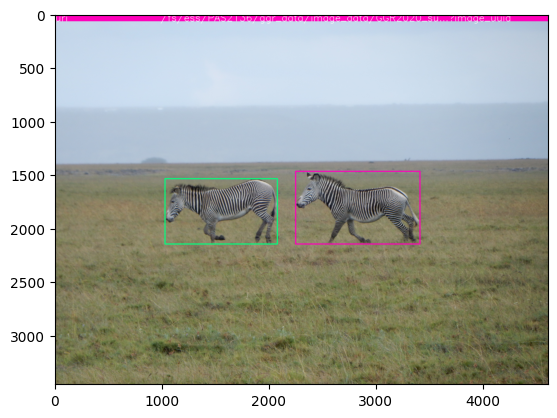

12
26    b6e7d7a5-341a-aa95-86be-3c5ec47e7e65
Name: image_uuid, dtype: object


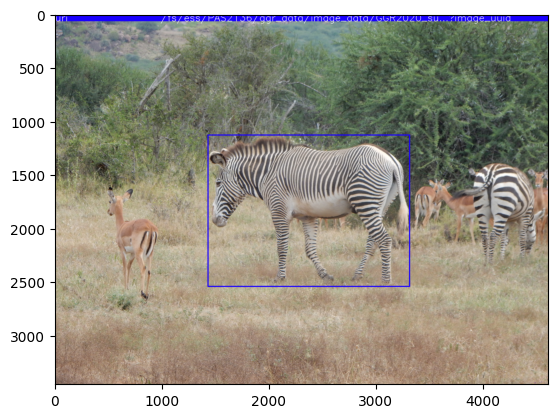

In [22]:
for uri in images:
    select = df[df["uri"] == uri]

    # Add the annots to the image
    if select.size > 0:
        print(select.size)
        print(select['image_uuid'])
        img = cv2.imread(uri)
        for _, row in select.iterrows():
            annot_str = format(row)
            bbox = np.array(row["bbox"]).astype(int)
            #color = np.random.randint(0, 256,  3).tolist()
            color_num = np.random.randint(0, 179)
            hsv_color = np.uint8([[[color_num, 255, 255]]])
            color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2RGB)
            color = color.flatten().tolist()
            # Bounding Box
            x1 = bbox[0]
            y1 = bbox[1]
            x2 = bbox[0] + bbox[2]
            y2 = bbox[1] + bbox[3]
            img = cv2.rectangle(img, (x1,y1), (x2,y2), color, thickness=10)

            # Text (commented lines are text placed ON bbox)
            (tw, th), _ = cv2.getTextSize(annot_str, cv2.FONT_HERSHEY_SIMPLEX, 3, 3)
            # img = cv2.rectangle(img, (x1, y1 - th - 2), (x1 + tw + 2, y1), color, -1)
            img = cv2.rectangle(img, (0, 0), (tw + 2, th + 2), color, -1)
            # Get the grayscale version of color s.t. we can contrast it
            gray_color = 0.299*color[0] + 0.587*color[1] + 0.114*color[2]
            if gray_color < 127.5:
                text_color = [255,255,255]
            else:
                text_color = [0,0,0]
            # img = cv2.putText(img, annot_str, (x1-1,y1+1), cv2.FONT_HERSHEY_SIMPLEX, 2, text_color, 2)
            img = cv2.putText(img, annot_str, (1,th+1), cv2.FONT_HERSHEY_SIMPLEX, 3, text_color, 3)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.show()
        